In [ ]:
pip install librosa numpy pandas scikit-learn tensorflow keras matplotlib seaborn


In [ ]:
# Download RAVDESS dataset
!pip install kaggle

# OR use this direct method with gdown (easier on Colab)
!pip install gdown

import gdown
import zipfile

# Download RAVDESS from Google Drive mirror
url = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
!wget -O ravdess.zip "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
!unzip -q ravdess.zip -d RAVDESS

--2026-05-16 10:02:35--  https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 188.184.103.118, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1188976/files/Audio_Speech_Actors_01-24.zip [following]
--2026-05-16 10:02:35--  https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 208468073 (199M) [application/octet-stream]
Saving to: ‘ravdess.zip’

ravdess.zip         100%[===================>] 198.81M  20.8MB/s    in 11s     

2026-05-16 10:02:46 (18.7 MB/s) - ‘ravdess.zip’ saved [208468073/208468073]



In [ ]:
import os

files = []
for root, dirs, filenames in os.walk("RAVDESS"):
    for f in filenames:
        if f.endswith(".wav"):
            files.append(os.path.join(root, f))

print(f"Total audio files found: {len(files)}")
print("Sample file:", files[0])

Total audio files found: 1440
Sample file: RAVDESS/Actor_02/03-01-06-01-01-02-02.wav


In [ ]:
import librosa
import numpy as np
import os

def extract_mfcc(file_path):
    audio, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc_scaled = np.mean(mfcc.T, axis=0)
    return mfcc_scaled

# Emotion mapping from RAVDESS filename
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

X = []
y = []

for root, dirs, filenames in os.walk("RAVDESS"):
    for f in filenames:
        if f.endswith(".wav"):
            emotion_code = f.split("-")[2]  # 3rd part of filename
            emotion_label = emotion_map.get(emotion_code)
            if emotion_label:
                file_path = os.path.join(root, f)
                mfcc = extract_mfcc(file_path)
                X.append(mfcc)
                y.append(emotion_code)  # keep as string for now

X = np.array(X)
print(f"X shape: {X.shape}")
print(f"Total samples: {len(y)}")
print(f"Unique emotions: {set(y)}")

X shape: (1440, 40)
Total samples: 1440
Unique emotions: {'07', '04', '02', '03', '06', '05', '08', '01'}


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Number of classes: {y_cat.shape[1]}")

Train: (1152, 40), Test: (288, 40)
Number of classes: 8


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Dense(256, activation='relu', input_shape=(40,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(8, activation='softmax')  # 8 emotions
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,704 (209.78 KB)

 Trainable params: 52,936 (206.78 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.1840 - loss: 2.3233 - val_accuracy: 0.1597 - val_loss: 10.0962 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2500 - loss: 2.0392 - val_accuracy: 0.1493 - val_loss: 5.9250 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2752 - loss: 1.9432 - val_accuracy: 0.2014 - val_loss: 3.5329 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3134 - loss: 1.8619 - val_accuracy: 0.2292 - val_loss: 2.4502 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3212 - loss: 1.8079 - val_accuracy: 0.2708 - val_loss: 1.9836 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3247 - loss: 1.7419 - val_accuracy: 0.3681 - val_loss: 1.6196 - learning_rate: 0.0010
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3411 - loss: 1.7286 - val_a

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")


Test Accuracy: 39.24%


In [ ]:
import librosa
import numpy as np
import os

def extract_features(file_path):
    audio, sr = librosa.load(file_path, duration=3, offset=0.5)

    # MFCCs
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc_delta = librosa.feature.delta(mfcc)

    # Chroma
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel_db = librosa.power_to_db(mel)

    # Combine all → mean of each
    combined = np.hstack([
        np.mean(mfcc.T, axis=0),         # 40
        np.mean(mfcc_delta.T, axis=0),   # 40
        np.mean(chroma.T, axis=0),       # 12
        np.mean(mel_db.T, axis=0)        # 128
    ])
    return combined  # total: 220 features

# Rebuild dataset
emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

X, y = [], []

for root, dirs, filenames in os.walk("RAVDESS"):
    for f in filenames:
        if f.endswith(".wav"):
            emotion_code = f.split("-")[2]
            if emotion_code in emotion_map:
                mfcc = extract_features(os.path.join(root, f))
                X.append(mfcc)
                y.append(emotion_code)

X = np.array(X)
print(f"New X shape: {X.shape}")

New X shape: (1440, 220)


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1152, 220), Test: (288, 220)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(8, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.1997 - loss: 2.4250 - val_accuracy: 0.3125 - val_loss: 1.8215 - learning_rate: 0.0010
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2396 - loss: 2.1484 - val_accuracy: 0.3715 - val_loss: 1.8004 - learning_rate: 0.0010
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2821 - loss: 2.0064 - val_accuracy: 0.3889 - val_loss: 1.6548 - learning_rate: 0.0010
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2977 - loss: 1.9028 - val_accuracy: 0.4549 - val_loss: 1.6060 - learning_rate: 0.0010
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3290 - loss: 1.7944 - val_accuracy: 0.4306 - val_loss: 1.5290 - learning_rate: 0.0010
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3498 - loss: 1.7236 - val_accuracy: 0.4167 - val_loss: 1.5024 - learning_rate: 0.0010
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3333 - loss: 1.7919 - val_accuracy: 0.44

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


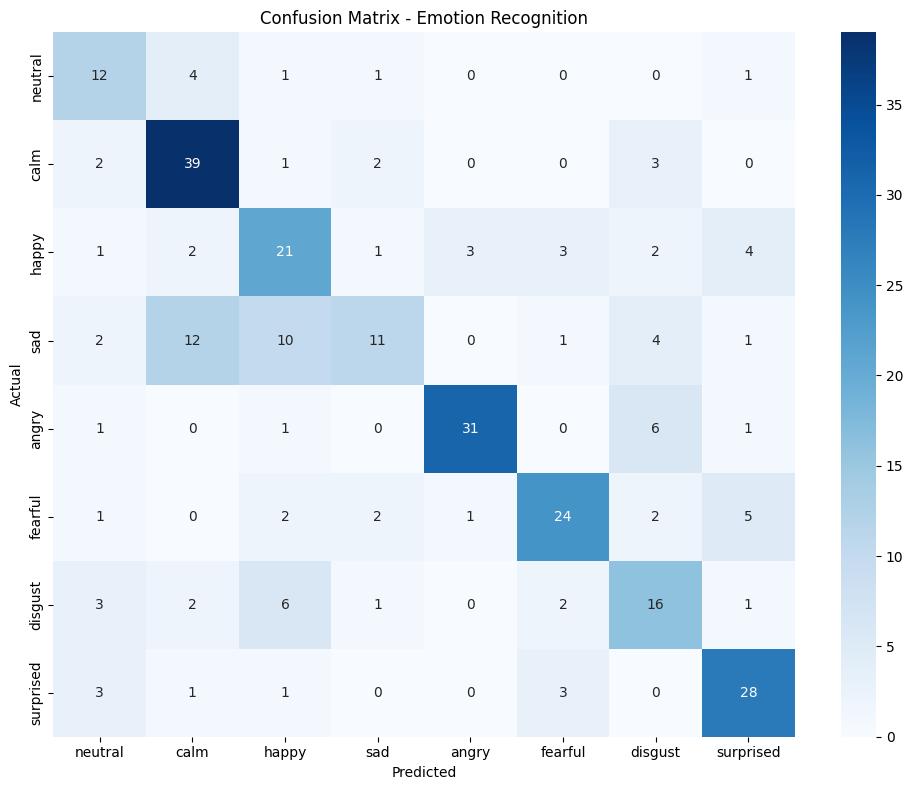


Classification Report:
              precision    recall  f1-score   support

     neutral       0.48      0.63      0.55        19
        calm       0.65      0.83      0.73        47
       happy       0.49      0.57      0.53        37
         sad       0.61      0.27      0.37        41
       angry       0.89      0.78      0.83        40
     fearful       0.73      0.65      0.69        37
     disgust       0.48      0.52      0.50        31
   surprised       0.68      0.78      0.73        36

    accuracy                           0.63       288
   macro avg       0.63      0.63      0.61       288
weighted avg       0.64      0.63      0.62       288



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

emotion_labels = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title("Confusion Matrix - Emotion Recognition")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=emotion_labels))

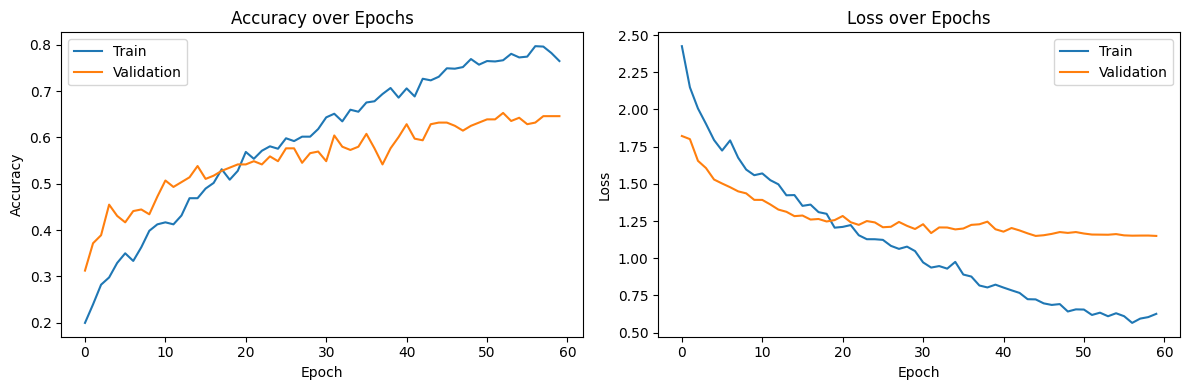

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def predict_emotion(file_path):
    features = extract_features(file_path)
    features_scaled = scaler.transform([features])
    prediction = model.predict(features_scaled, verbose=0)
    emotion_labels = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']
    predicted = emotion_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100
    print(f"Predicted Emotion : {predicted}")
    print(f"Confidence        : {confidence:.2f}%")

# Test with any file from dataset
predict_emotion(files[0])

Predicted Emotion : fearful
Confidence        : 94.43%


In [ ]:
# CNN+LSTM needs 3D input: (samples, timesteps, features)
X_cnn = X_scaled.reshape(X_scaled.shape[0], 20, 11)  # 220 features → 20 timesteps x 11 features

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cat, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train_cnn.shape}")  # (1152, 20, 11)
print(f"Test shape : {X_test_cnn.shape}")   # (288, 20, 11)

Train shape: (1152, 20, 11)
Test shape : (288, 20, 11)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization

model_cnn_lstm = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(20, 11)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(128, return_sequences=False),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='softmax')
])

model_cnn_lstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 64)         │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 18, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 9, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,008 (656.28 KB)

 Trainable params: 167,624 (654.78 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history_cnn = model_cnn_lstm.fit(
    X_train_cnn, y_train_cnn,
    epochs=150,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cnn),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

loss, accuracy = model_cnn_lstm.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.2318 - loss: 1.9540 - val_accuracy: 0.3264 - val_loss: 1.8295 - learning_rate: 0.0010
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2535 - loss: 1.8595 - val_accuracy: 0.3438 - val_loss: 1.7605 - learning_rate: 0.0010
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2917 - loss: 1.7883 - val_accuracy: 0.3229 - val_loss: 1.7635 - learning_rate: 0.0010
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3047 - loss: 1.7584 - val_accuracy: 0.3403 - val_loss: 1.7126 - learning_rate: 0.0010
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2995 - loss: 1.7335 - val_accuracy: 0.3438 - val_loss: 1.7074 - learning_rate: 0.0010
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3247 - loss: 1.6927 - val_accuracy: 0.3715 - val_loss: 1.6507 - learning_rate: 0.0010
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3550 - loss: 1.6760 - 

In [ ]:
import librosa
import numpy as np
import os

def extract_features(audio, sr):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc_delta = librosa.feature.delta(mfcc)
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    mel = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel_db = librosa.power_to_db(mel)
    return np.hstack([
        np.mean(mfcc.T, axis=0),
        np.mean(mfcc_delta.T, axis=0),
        np.mean(chroma.T, axis=0),
        np.mean(mel_db.T, axis=0)
    ])

def augment_audio(audio, sr):
    augmented = []

    # Original
    augmented.append(audio)

    # Add noise
    noise = audio + 0.005 * np.random.randn(len(audio))
    augmented.append(noise)

    # Pitch shift up
    pitched_up = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
    augmented.append(pitched_up)

    # Pitch shift down
    pitched_down = librosa.effects.pitch_shift(audio, sr=sr, n_steps=-2)
    augmented.append(pitched_down)

    # Time stretch
    stretched = librosa.effects.time_stretch(audio, rate=1.1)
    augmented.append(stretched)

    return augmented

emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

X, y = [], []

for root, dirs, filenames in os.walk("RAVDESS"):
    for f in filenames:
        if f.endswith(".wav"):
            emotion_code = f.split("-")[2]
            if emotion_code in emotion_map:
                file_path = os.path.join(root, f)
                audio, sr = librosa.load(file_path, duration=3, offset=0.5)
                for aug_audio in augment_audio(audio, sr):
                    features = extract_features(aug_audio, sr)
                    X.append(features)
                    y.append(emotion_code)

X = np.array(X)
print(f"Total samples after augmentation: {len(X)}")
print(f"X shape: {X.shape}")

KeyboardInterrupt: 

In [ ]:
import librosa
import numpy as np
import os

def extract_features(audio, sr):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc_delta = librosa.feature.delta(mfcc)
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    mel = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel_db = librosa.power_to_db(mel)
    return np.hstack([
        np.mean(mfcc.T, axis=0),
        np.mean(mfcc_delta.T, axis=0),
        np.mean(chroma.T, axis=0),
        np.mean(mel_db.T, axis=0)
    ])

def augment_audio(audio, sr):
    augmented = []

    # Original
    augmented.append(audio)

    # Add noise
    noise = audio + 0.005 * np.random.randn(len(audio))
    augmented.append(noise)

    # Pitch shift up
    pitched_up = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
    augmented.append(pitched_up)

    # Pitch shift down
    pitched_down = librosa.effects.pitch_shift(audio, sr=sr, n_steps=-2)
    augmented.append(pitched_down)

    # Time stretch
    stretched = librosa.effects.time_stretch(audio, rate=1.1)
    augmented.append(stretched)

    return augmented

emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

X, y = [], []

for root, dirs, filenames in os.walk("RAVDESS"):
    for f in filenames:
        if f.endswith(".wav"):
            emotion_code = f.split("-")[2]
            if emotion_code in emotion_map:
                file_path = os.path.join(root, f)
                audio, sr = librosa.load(file_path, duration=3, offset=0.5)
                for aug_audio in augment_audio(audio, sr):
                    features = extract_features(aug_audio, sr)
                    X.append(features)
                    y.append(emotion_code)

X = np.array(X)
print(f"Total samples after augmentation: {len(X)}")
print(f"X shape: {X.shape}")

Total samples after augmentation: 7200
X shape: (7200, 220)


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(8, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

Train: (5760, 220), Test: (1440, 220)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.2205 - loss: 2.2154 - val_accuracy: 0.3354 - val_loss: 1.7619 - learning_rate: 0.0010
Epoch 2/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2851 - loss: 1.8721 - val_accuracy: 0.3806 - val_loss: 1.6385 - learning_rate: 0.0010
Epoch 3/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3224 - loss: 1.7617 - val_accuracy: 0.3938 - val_loss: 1.5779 - learning_rate: 0.0010
Epoch 4/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3549 - loss: 1.6837 - val_accuracy: 0.4028 - val_loss: 1.5256 - learning_rate: 0.0010
Epoch 5/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3884 - loss: 1.6409 - val_accuracy: 0.4194 - val_loss: 1.5050 - learning_rate: 0.0010
Epoch 6/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3976 - loss: 1.5883 - val_accuracy: 0.4347 - val_loss: 1.4567 - learning_rate: 0.0010
Epoch 7/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4196 - loss: 1

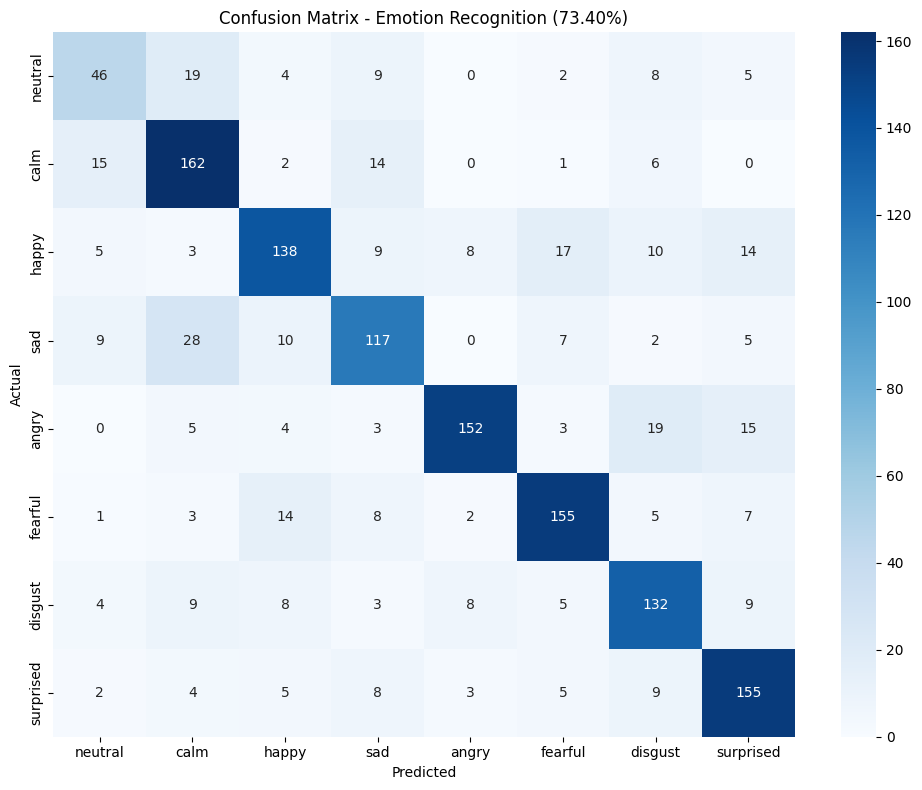

              precision    recall  f1-score   support

     neutral       0.56      0.49      0.53        93
        calm       0.70      0.81      0.75       200
       happy       0.75      0.68      0.71       204
         sad       0.68      0.66      0.67       178
       angry       0.88      0.76      0.81       201
     fearful       0.79      0.79      0.79       195
     disgust       0.69      0.74      0.72       178
   surprised       0.74      0.81      0.77       191

    accuracy                           0.73      1440
   macro avg       0.72      0.72      0.72      1440
weighted avg       0.74      0.73      0.73      1440



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

emotion_labels = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title("Confusion Matrix - Emotion Recognition (73.40%)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_true_classes, y_pred_classes, target_names=emotion_labels))

In [ ]:
model.save("emotion_model.h5")
import joblib
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")
print("Model saved!")

Model saved!


In [ ]:
import joblib

def predict_emotion(file_path):
    audio, sr = librosa.load(file_path, duration=3, offset=0.5)
    features = extract_features(audio, sr)
    features_scaled = scaler.transform([features])
    prediction = model.predict(features_scaled, verbose=0)
    emotion_labels = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']
    predicted = emotion_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100
    print(f"Predicted Emotion : {predicted}")
    print(f"Confidence        : {confidence:.2f}%")

# Test it
predict_emotion(files[10])


Predicted Emotion : disgust
Confidence        : 99.91%
